In [56]:
from keras import layers, Sequential, callbacks, applications
from keras.preprocessing import image_dataset_from_directory

import pandas as pd

In [57]:
data_dir = "../../data/eye_disease"

seed = 1
size = 299

batch_size = 8

shuffle = True

val_split = 0.2

ds_train = image_dataset_from_directory(
    data_dir,
    validation_split=val_split,
    seed=seed,
    subset="training",
    image_size=(size,size),
    batch_size=batch_size,
    shuffle=shuffle
)
ds_valid= image_dataset_from_directory(
    data_dir,
    validation_split=val_split,
    seed=seed,
    subset="validation",
    image_size=(size,size),
    batch_size=batch_size,
    shuffle=shuffle
)
num_classes = 4
class_names = ds_train.class_names

Found 4217 files belonging to 4 classes.
Using 3374 files for training.
Found 4217 files belonging to 4 classes.
Using 843 files for validation.


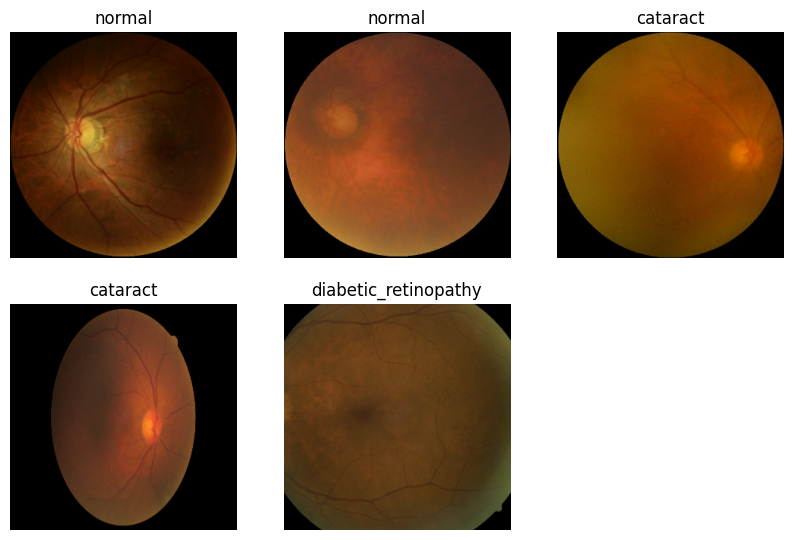

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in ds_train.take(1):
  for i in range(5):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [59]:
body = applications.Xception(weights="imagenet")
body.trainable = False

model_layers = [
    layers.Rescaling(1./255),
    
    body,
    
    layers.Flatten(),
    layers.Dense(32, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
]

In [60]:
model = Sequential(layers=model_layers)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["sparse_categorical_accuracy"]
)

In [61]:
early_stopping = callbacks.EarlyStopping(
    patience=5,
    min_delta=5e-4,
    restore_best_weights=True
)
history = model.fit(
    ds_train,
    validation_data=ds_valid,
    callbacks=[early_stopping],
    epochs=500
)

Epoch 1/500
422/422 ━━━━━━━━━━━━━━━━━━━━ 38s 72ms/step - loss: 1.2015 - sparse_categorical_accuracy: 0.5249 - val_loss: 1.0203 - val_sparse_categorical_accuracy: 0.5480
Epoch 2/500
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - loss: 0.9705 - sparse_categorical_accuracy: 0.5862 - val_loss: 0.9228 - val_sparse_categorical_accuracy: 0.5718
Epoch 3/500
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - loss: 0.9084 - sparse_categorical_accuracy: 0.6129 - val_loss: 0.8782 - val_sparse_categorical_accuracy: 0.6157
Epoch 4/500
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - loss: 0.8716 - sparse_categorical_accuracy: 0.6357 - val_loss: 0.8488 - val_sparse_categorical_accuracy: 0.6465
Epoch 5/500
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - loss: 0.8450 - sparse_categorical_accuracy: 0.6479 - val_loss: 0.8255 - val_sparse_categorical_accuracy: 0.6512
Epoch 6/500
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - loss: 0.8223 - sparse_categorical_accuracy: 0.6609 - val_loss: 0.8086 - val_sparse_categorical_acc

<Axes: >

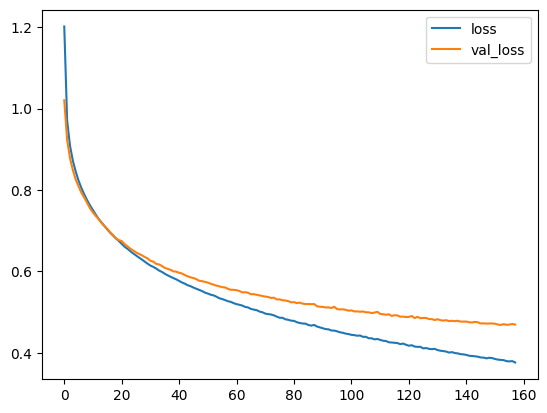

In [62]:
history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot()